1\. Environment Setup
---------------------

The authors utilized a Linux-based server with NVIDIA RTX GPUs. For this replication, we use **Detectron2**, a standard library for object detection research.

**Kaggle Note:** We install Detectron2 from source to ensure compatibility with Kaggle's pre-installed PyTorch version. We also ensure pyyaml is pinned to prevent dependency conflicts.

In [1]:
# Installation (Uncomment if needed)
# !pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu111/torch1.9/index.html

!pip install git+https://github.com/facebookresearch/detectron2.git

import os
import copy
import torch
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image
import xml.etree.ElementTree as ET

# Detectron2 imports
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, default_setup
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader
from detectron2.data import transforms as T
from detectron2.data import detection_utils as utils
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.structures import BoxMode

# Define Output Directory for Kaggle (Writable path)
OUTPUT_DIR = "/kaggle/working/output/naive_ddl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Using Torch version: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-oa68cqtj
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-oa68cqtj
  Resolved https://github.com/facebookresearch/detectron2.git to commit 8a9d885b3d4dcf1bef015f0593b872ed8d32b4ab
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 8.2 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6733272 sha256=166afacbd7869fce277c765ea31d2388ecab765235e967949d145b095dfef4d1
  Stored in directory: /tmp/pip-ephem-wheel-cache-jd0x4df9/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=e3ed2df1bdd0c629cb3318859

2\. Dataset Registration
------------------------

As per **Section 3.1**, the dataset consists of 5,900 images of paprika plants. We follow the paper's split:

*   **70% Training**
    
*   **10% Validation**
    
*   **20% Testing**
    

The DDL unit focuses on 6 abnormality categories found in the Paprika dataset.

In [2]:
# 6 Classes from the dataset README
CLASS_NAMES = [
    "blossom_end_rot",
    "graymold",
    "powdery_mildew",
    "spider_mite",
    "spotting_disease",
    "snails_and_slugs"
]

# EXACT KAGGLE PATHS
DATASET_ROOT = "/kaggle/input/datasets/tijesu26/paprika-dataset/data" 
TEST_ROOT = "/kaggle/input/datasets/tijesu26/paprika-dataset/test_data"

def get_paprika_dicts(img_dir, label_dir):
    """
    Parses YOLO format dataset (Train/Valid) for Detectron2.
    """
    dataset_dicts = []
    image_files = glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png"))
    
    print(f"Found {len(image_files)} images in {img_dir}")
    
    for idx, img_path in enumerate(image_files):
        record = {}
        with Image.open(img_path) as img:
            width, height = img.size
            
        record["file_name"] = img_path
        record["image_id"] = img_path 
        record["height"] = height
        record["width"] = width
        
        filename = os.path.basename(img_path)
        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(label_dir, label_filename)
        
        objs = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5: continue
                
                # YOLO: class_id, center_x, center_y, width, height (Normalized)
                class_id = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                
                # Conversion to Absolute XYXY
                abs_cx = cx * width
                abs_cy = cy * height
                abs_w = w * width
                abs_h = h * height
                
                x_min = abs_cx - (abs_w / 2)
                y_min = abs_cy - (abs_h / 2)
                x_max = abs_cx + (abs_w / 2)
                y_max = abs_cy + (abs_h / 2)
                
                obj = {
                    "bbox": [x_min, y_min, x_max, y_max],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "category_id": class_id,
                }
                objs.append(obj)
        
        record["annotations"] = objs
        dataset_dicts.append(record)
        
    return dataset_dicts

def get_paprika_dicts_xml(img_dir, xml_dir):
    """
    Parses PASCAL VOC (XML) format dataset (Test) for Detectron2.
    """
    dataset_dicts = []
    image_files = glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png"))
    
    print(f"Found {len(image_files)} test images in {img_dir}")
    
    for idx, img_path in enumerate(image_files):
        record = {}
        filename = os.path.basename(img_path)
        xml_filename = os.path.splitext(filename)[0] + ".xml"
        xml_path = os.path.join(xml_dir, xml_filename)
        
        if not os.path.exists(xml_path):
            continue
            
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        size = root.find("size")
        width = int(size.find("width").text)
        height = int(size.find("height").text)
            
        record["file_name"] = img_path
        record["image_id"] = img_path 
        record["height"] = height
        record["width"] = width
        
        objs = []
        for member in root.findall("object"):
            class_name = member.find("name").text
            
            # Map string name to our integer class_id
            if class_name in CLASS_NAMES:
                class_id = CLASS_NAMES.index(class_name)
            else:
                continue # Skip unrecognized classes
                
            bndbox = member.find("bndbox")
            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)
            
            obj = {
                "bbox": [xmin, ymin, xmax, ymax],
                "bbox_mode": BoxMode.XYXY_ABS,
                "category_id": class_id,
            }
            objs.append(obj)
            
        record["annotations"] = objs
        dataset_dicts.append(record)
        
    return dataset_dicts

def register_paprika_datasets():
    # 1. Register Train and Valid (YOLO Format)
    for split in ["train", "valid"]:
        name = f"paprika_{split}"
        img_dir = os.path.join(DATASET_ROOT, split, "images")
        label_dir = os.path.join(DATASET_ROOT, split, "labels")
        
        if os.path.exists(img_dir):
            DatasetCatalog.register(name, lambda d=img_dir, l=label_dir: get_paprika_dicts(d, l))
            MetadataCatalog.get(name).set(thing_classes=CLASS_NAMES)
            print(f"Successfully Registered: {name}")

    # 2. Register Test Data (XML Format)
    test_name = "paprika_test"
    test_img_dir = os.path.join(TEST_ROOT, "images")
    test_xml_dir = os.path.join(TEST_ROOT, "xml")
        
    if os.path.exists(test_img_dir) and os.path.exists(test_xml_dir):
        DatasetCatalog.register(test_name, lambda d=test_img_dir, x=test_xml_dir: get_paprika_dicts_xml(d, x))
        MetadataCatalog.get(test_name).set(thing_classes=CLASS_NAMES)
        print(f"Successfully Registered: {test_name}")
    else:
        print(f"Warning: Test directories not found at {test_img_dir} or {test_xml_dir}")

# Clear previous registrations if re-running
DatasetCatalog.clear()
register_paprika_datasets()


Successfully Registered: paprika_train
Successfully Registered: paprika_valid
Successfully Registered: paprika_test


In [3]:
# DatasetCatalog.get("paprika_train")

Found 10342 images in /kaggle/input/datasets/tijesu26/paprika-dataset/data/train/images


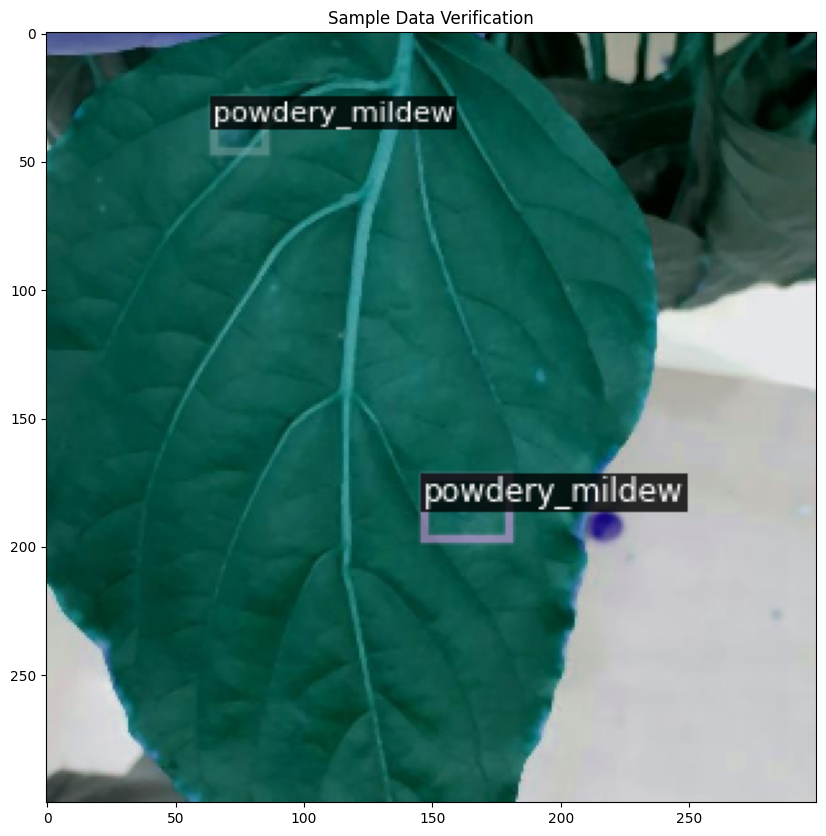

In [4]:
# Verification
if "paprika_train" in DatasetCatalog.list():
    dataset_dicts = DatasetCatalog.get("paprika_train")
    if len(dataset_dicts) > 0:
        d = dataset_dicts[20]
        img = utils.read_image(d["file_name"], format="BGR")
        visualizer = Visualizer(img[:, :, ::-1], metadata= MetadataCatalog.get("paprika_train"), scale=0.5)
                
        # === REDUCE TEXT SIZE ===
        # Manually override the calculated font size
        # Try values between 10 (small) and 25 (large)
        # visualizer._default_font_size = 15
        
        out = visualizer.draw_dataset_dict(d)
        plt.figure(figsize=(10, 10))
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.title("Sample Data Verification")
        plt.show()
    else:
        print("Dataset registered but no images found.")

## 3. Augmentation Strategy

We implement the specific augmentations mentioned in **Table 4** of the paper.
The authors noted that *Color Temperature* and *Noise* reduced performance, while *Geometric* transforms improved it.

**Implemented Transforms:**
1.  **Random Flip:** Probability 0.9 (Horizontal).
2.  **Scale/Resize:** Table 4 lists `Scale x=[0.8, 1.2]`. In Detectron2, we implement this via `ResizeShortestEdge` with a range of sizes to simulate multi-scale training around the 1024px baseline.


In [5]:
def custom_mapper(dataset_dict):
    """
    Custom mapper to implement Table 4 augmentations.
    """
    dataset_dict = copy.deepcopy(dataset_dict)
    
    # Read image
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    
    # Baseline input size from Table 5 is 1024x1024
    # We create a range [0.8 * 1024, 1.2 * 1024] -> [819, 1228]
    min_size_range = (820, 1220) 
    
    transform_list = [
        # Table 4: Random Flip (prob=0.9)
        T.RandomFlip(prob=0.9, horizontal=True, vertical=False),
        
        # Table 4: Scale [0.8, 1.2]
        # We sample the shortest edge from the range to achieve scaling
        T.ResizeShortestEdge(short_edge_length=min_size_range, max_size=1333, sample_style='range'),
    ]
    
    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    # Apply transforms to annotations (bounding boxes)
    if "annotations" in dataset_dict:
        annos = [
            utils.transform_instance_annotations(obj, transforms, image.shape[:2])
            for obj in dataset_dict.pop("annotations")
            if obj.get("iscrowd", 0) == 0
        ]
        instances = utils.annotations_to_instances(annos, image.shape[:2])
        dataset_dict["instances"] = utils.filter_empty_instances(instances)
    
    return dataset_dict

### 3.1 Custom Trainer Definition

# We subclass `DefaultTrainer` to hook in our `custom_mapper`.

class NaiveDDLTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        # Swap standard loader for our custom mapper
        return build_detection_train_loader(cfg, mapper=custom_mapper)

## 4. Model Configuration (Naïve DDL)
  - **Optimizer:** SGD
  - **Momentum:** 0.9
  - **Base LR:** 0.08 (with Cosine Decay)
  - **Weight Decay:** 0.0005
  - **Batch Size:** 16
  - **Max Iterations:** 100,000

<!-- end list -->

In [6]:
def setup_cfg():
    cfg = get_cfg()
    
    # 1. Architecture: Faster R-CNN R50 FPN (Matches Table 5 Naive Framework)
    cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
    
    # 2. Dataset Registry (Updated to match the split names we registered)
    cfg.DATASETS.TRAIN = ("paprika_train",)
    cfg.DATASETS.TEST = ("paprika_valid",) # Using 'valid' as test
    cfg.DATALOADER.NUM_WORKERS = 2  
    
    # 3. Solver / Training Config (Table 3)
    # Note: 16 batch size requires high VRAM. On Kaggle P100 (16GB), use 4 or 8.
    # We scale LR accordingly: 0.08 is for batch 16. If batch 4, LR -> 0.02
    cfg.SOLVER.IMS_PER_BATCH = 4        
    cfg.SOLVER.BASE_LR = 0.02           
    
    cfg.SOLVER.MOMENTUM = 0.9
    cfg.SOLVER.WEIGHT_DECAY = 0.0005
    cfg.SOLVER.MAX_ITER = 10000          # Reduced for Kaggle Demo (Paper: 100000)
    cfg.SOLVER.WARMUP_ITERS = 1000      # 0-1K Warmup
    
    # 4. Learning Rate Scheduler
    cfg.SOLVER.LR_SCHEDULER_NAME = "WarmupCosineLR"
    
    # 5. Input Resolution (Table 5: 1024x1024)
    cfg.INPUT.MIN_SIZE_TRAIN = (1024,)
    cfg.INPUT.MAX_SIZE_TRAIN = 1024
    cfg.INPUT.MIN_SIZE_TEST = 1024
    cfg.INPUT.MAX_SIZE_TEST = 1024
    
    # 6. Model Heads
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512 
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 6  # 6 Paprika anomalies
    
    # 7. Output
    cfg.OUTPUT_DIR = OUTPUT_DIR
    
    return cfg

cfg = setup_cfg()

## 5\. Training Loop

We initialize the custom trainer and start the process.

In [7]:
# Initialize the trainer with our custom mapper
# trainer = NaiveDDLTrainer(cfg)

# # Load ImageNet pretrained weights (standard for D2)
# trainer.resume_or_load(resume=False)

# # Start Training
# print(f"Starting Training: {datetime.now()}")
# print(f"Configured for {cfg.SOLVER.MAX_ITER} iterations.")

In [8]:
# Uncomment below to run training
# trainer.train()

In [9]:
# ==========================================
# 1. LOAD THE TRAINED WEIGHTS
# ==========================================
# Update this if you uploaded your model as a Kaggle dataset!
# E.g., "/kaggle/input/diana-naive-ddl-weights/model_final.pth"
cfg.MODEL.WEIGHTS = "/kaggle/input/notebooks/tijesu26/paprika-ddl-implementation/output/naive_ddl/model_final.pth"  
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   

predictor = DefaultPredictor(cfg)

# ==========================================
# 2. QUANTITATIVE EVALUATION (mAP Score)
# ==========================================
print("Running Quantitative Evaluation on VALIDATION DATA...")
try:
    # Reverted to evaluate rigorous metrics on the validation set
    evaluator = COCOEvaluator("paprika_valid", output_dir=OUTPUT_DIR)
    val_loader = build_detection_test_loader(cfg, "paprika_valid")
    evaluation_results = inference_on_dataset(predictor.model, val_loader, evaluator)
    print(evaluation_results)
except Exception as e:
    print(f"Error during evaluation: {e}")

# ==========================================
# 3. QUALITATIVE VISUALIZATION
# ==========================================
print("\nVisualizing Predictions on TEST DATA...")
# Draws boxes on your held-out visual inspection set
test_dataset = DatasetCatalog.get("paprika_test")

# Pick 3 random images (or use min(3, len(test_dataset)) if test set is small)
import random
samples = random.sample(test_dataset, min(10, len(test_dataset)))

for d in samples:    
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)
    instances = outputs["instances"].to("cpu")
    
    # Extract prediction details
    num_instances = len(instances)
    pred_classes = instances.pred_classes.numpy()
    pred_scores = instances.scores.numpy()
    
    # Create simple numbered labels (1, 2, 3...) for the image
    numbered_labels = [str(i + 1) for i in range(num_instances)]
    
    # Create the detailed legend text
    legend_texts = []
    for i in range(num_instances):
        class_name = CLASS_NAMES[pred_classes[i]]
        score = pred_scores[i] * 100
        legend_texts.append(f"Box {i + 1}: {class_name} ({score:.1f}%)")
    
    v = Visualizer(im[:, :, ::-1],
                   metadata=MetadataCatalog.get("paprika_test"), 
                   scale=0.5)
    
    # Dynamically scale text size based on image resolution
    # Takes 2% of the largest dimension, with a minimum size of 12
    h, w = im.shape[:2]
    dynamic_font_size = max(12, int(max(h, w) * 0.02))
    v._default_font_size = dynamic_font_size 
    
    # Overlay using our custom numbered labels instead of the default class names
    out = v.overlay_instances(
        boxes=instances.pred_boxes if instances.has("pred_boxes") else None,
        labels=numbered_labels
    )
    
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(out.get_image()[:, :, ::-1])
    plt.title(f"Test Prediction: {os.path.basename(d['file_name'])}")
    plt.axis("off")
    plt.show()
    
    # Print the legend directly below the image
    if num_instances > 0:
        print("Detected Anomalies:")
        for text in legend_texts:
            print(f"  - {text}")
    else:
        print("No anomalies detected.")
    print("=" * 60)

NameError: name 'DefaultPredictor' is not defined